# LeetCode #38: Count and Say

https://leetcode.com/problems/count-and-say/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Recursive** | $O(2^n)$ | $O(2^n)$ |
| **Iterative RLE** ★ | $O(2^n)$ | $O(2^n)$ |

---

## Understanding the Methods

### Brute Force (Recursion)
Recursively call `countAndSay(n-1)`, then run-length encode the result. Both approaches are equivalent in complexity; recursion adds call-stack overhead up to depth n.

### Optimal: Iterative RLE ★
Start with `current = "1"` and iterate n-1 times. Each iteration, scan `current` character by character, counting consecutive identical digits and appending `count + digit` to a StringBuilder. The result replaces `current`. Iterative form avoids recursion overhead and is easy to read.

**The sequence grows sub-exponentially in practice** but the worst-case growth rate is bounded by $O(2^n)$.

**Constraints:**
* $1 \leq n \leq 30$

## Solutions

### C#

In [ ]:
public class Solution {
    public string CountAndSay(int n) {
        string current = "1";
        for (int i = 1; i < n; i++) {
            var sb = new System.Text.StringBuilder();
            int j = 0;
            while (j < current.Length) {
                char ch = current[j];
                int count = 0;
                while (j < current.Length && current[j] == ch) { j++; count++; }
                sb.Append(count).Append(ch);
            }
            current = sb.ToString();
        }
        return current;
    }
}

### Python

In [ ]:
import itertools

class Solution:
    def countAndSay(self, n: int) -> str:
        current = '1'
        for _ in range(n - 1):
            nxt = []
            for ch, group in itertools.groupby(current):
                nxt.append(str(len(list(group))))
                nxt.append(ch)
            current = ''.join(nxt)
        return current

### Go

In [ ]:
package main

import "strconv"

func countAndSay(n int) string {
	current := "1"
	for i := 1; i < n; i++ {
		var res []byte
		j := 0
		for j < len(current) {
			ch := current[j]
			count := 0
			for j < len(current) && current[j] == ch {
				j++
				count++
			}
			res = append(res, []byte(strconv.Itoa(count))...)
			res = append(res, ch)
		}
		current = string(res)
	}
	return current
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn count_and_say(n: i32) -> String {
        let mut current = String::from("1");
        for _ in 1..n {
            let bytes = current.as_bytes();
            let mut res = String::new();
            let mut j = 0;
            while j < bytes.len() {
                let ch = bytes[j];
                let mut count = 0;
                while j < bytes.len() && bytes[j] == ch {
                    j += 1;
                    count += 1;
                }
                res.push_str(&count.to_string());
                res.push(ch as char);
            }
            current = res;
        }
        current
    }
}

## Example Scenarios

### 1. Common Case — Building the Sequence Step by Step
**Input:** n = 4
Start: "1". Iteration 1: one 1 → "11". Iteration 2: two 1s → "21". Iteration 3: one 2, one 1 → "1211".
**Why tricky:** The core RLE logic: scan left-to-right, count consecutive identical digits, emit count+digit. This verifies the basic loop works.

**Output:** `"1211"`

### 2. Slightly Complex — Digit 3 Appears for the First Time
**Input:** n = 6
Sequence: "1" → "11" → "21" → "1211" → "111221" → "312211". At n=5, "1211" has three 1s at the start (the 1 from "12" and "11"), producing "111221". At n=6, those three 1s yield "31".
**Why tricky:** Seeing digit 3 for the first time. Students often doubt whether digits > 2 can appear. The adjacent-group boundary between "12" and "11" in "1211" creates a run of three 1s.

**Output:** `"312211"`

### 3. Edge Case: Time Factor — Maximum Constraint (n = 30)
**Input:** n = 30
The string length grows exponentially by Conway's constant $\lambda \approx 1.3036$ each step. At n=30, the string is $\approx 9546$ characters. Total work across all iterations: $\sum_{i=1}^{29} \lambda^i \approx O(\lambda^{30}) \approx O(10^4)$.
**Why tricky:** The output size is exponential in n, but $\lambda^{30} \approx 9546$ is still manageable. Interviewers may ask about the growth rate — knowing Conway's constant shows depth.

**Output:** A 9546-character string — $O(\lambda^n)$ time and space.

### 4. Edge Case: Space Factor — Base Case (n = 1)
**Input:** n = 1
Return "1" immediately. Zero iterations, zero string allocations beyond the result.
**Why tricky:** Tests the base case: does the loop execute at all? An off-by-one error (iterating once) would return "11" instead. $O(1)$ space — only the result string.

**Output:** `"1"`

### 5. Almost-Impossible but Plausible — Proving Only Digits {1, 2, 3} Appear
**Input:** n = 30 — does digit 4+ ever appear?
If "dddd" (4 identical digits) appeared at step k, then step k-1 must have contained a segment that RLE-encodes to "4d". But "4d" means step k-1 had four consecutive d's — which at step k-2 would have produced "4d" or been split. By induction, no sequence starting from "1" can produce a run of 4+ identical digits.
**Why tricky:** Conway's Cosmological Theorem formally proves this. A common follow-up question in interviews: "can digit 4 appear?" The answer is no — and the argument is by contradiction on the RLE encoding.

**Output:** The string for n=30 contains **only digits {1, 2, 3}**.

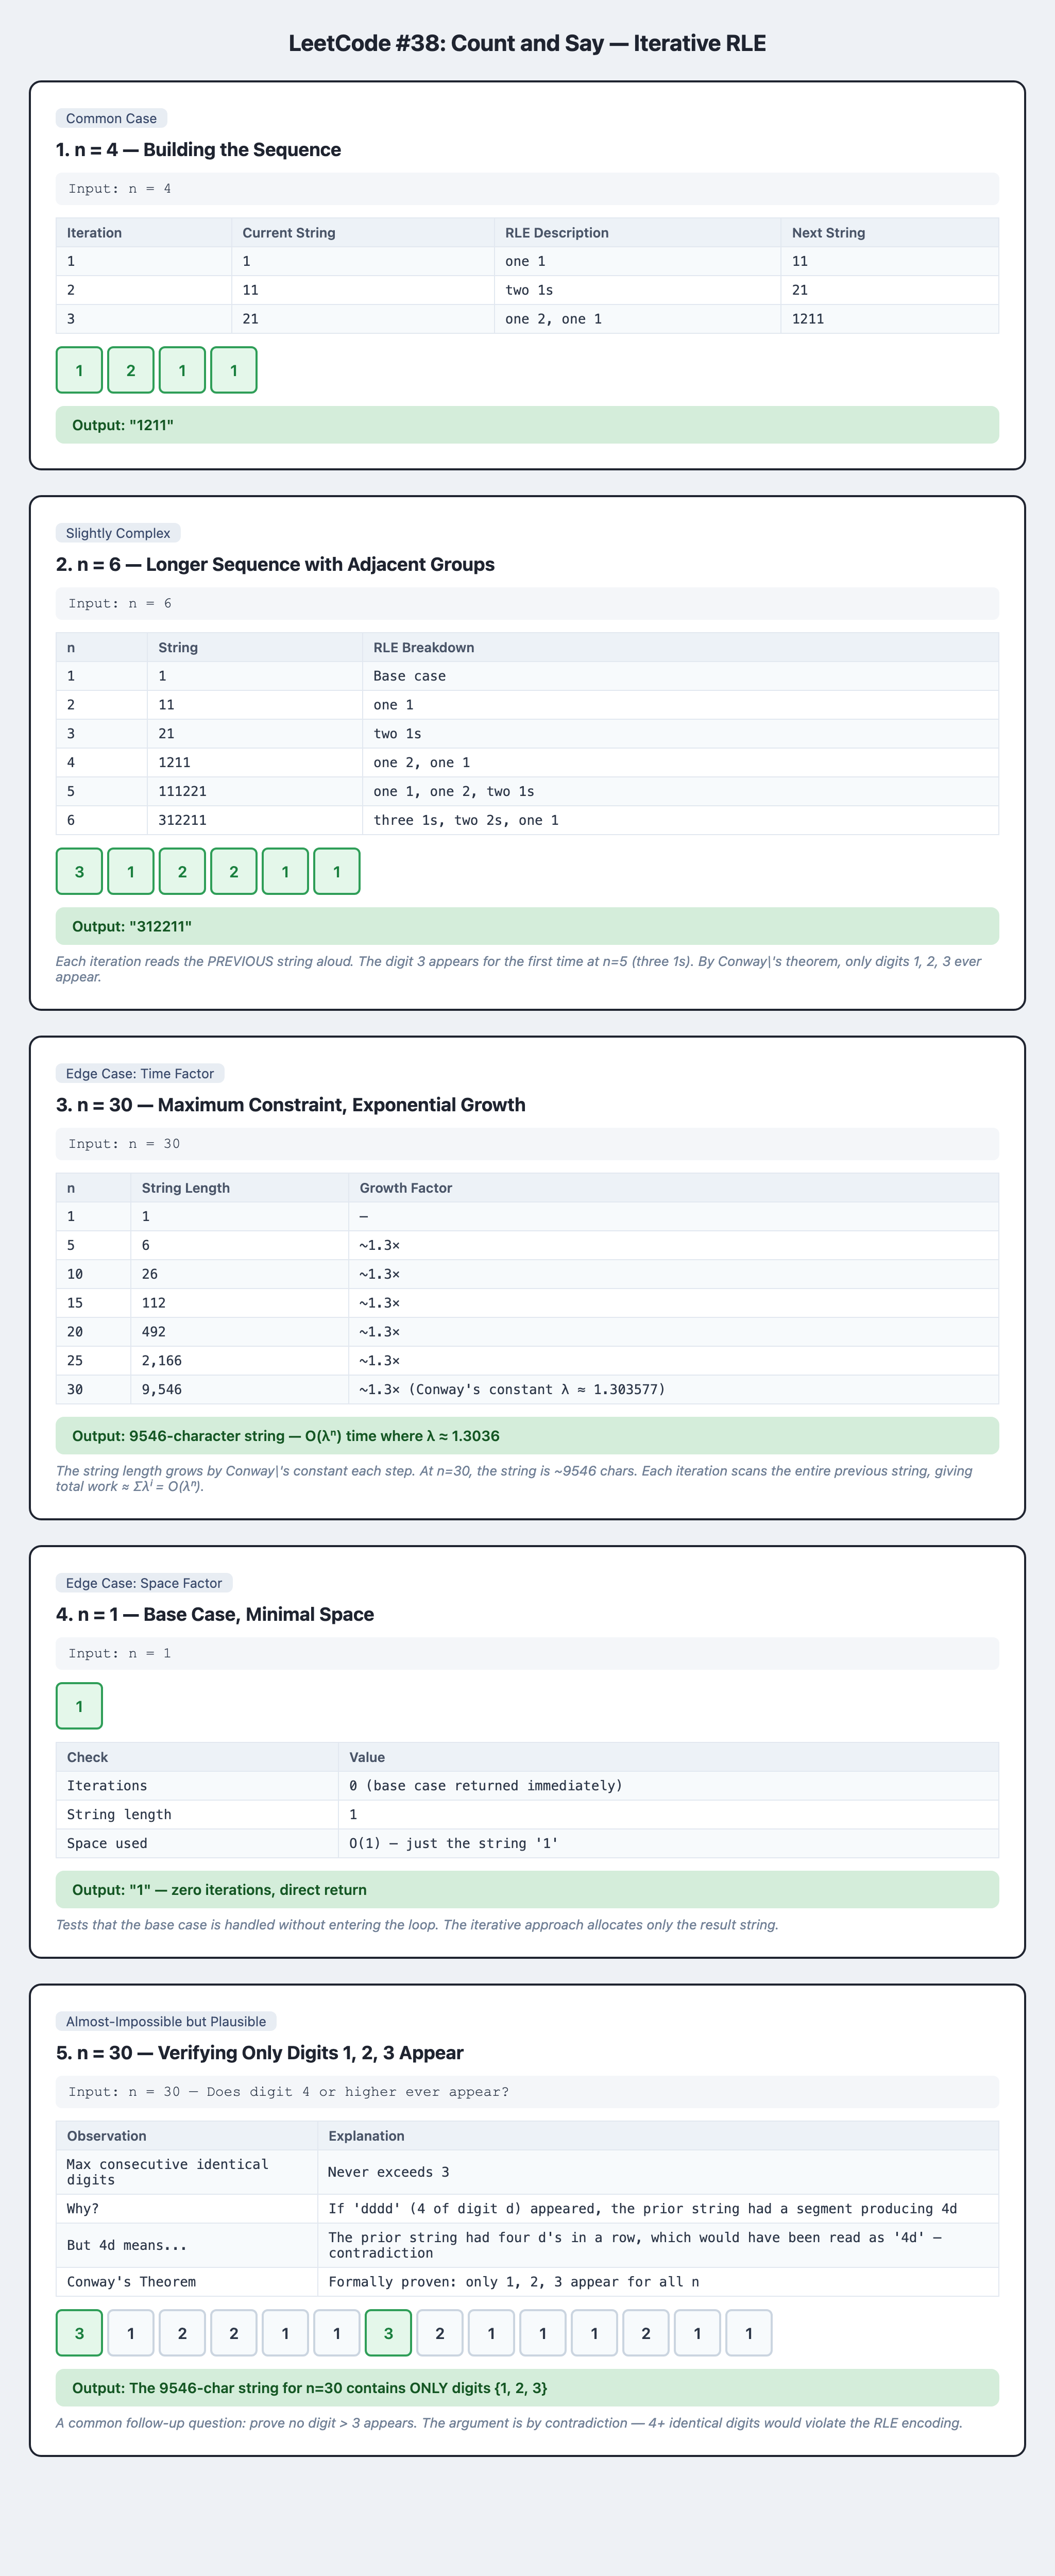